# Chronos-2 Quality Net — Results, 실측치(measured-actual) 데이터 재실행 (2026-09-05)

Cement 폴더에 새로 추가된 `운전&품질데이터_실측치.xlsx`를 원본 소스로 삼아, 지금까지 context_length
스윕에서 타깃별로 가장 성능이 좋았던 설정(2026-08-28 사용자 확정: **blaine=1024, residue=1536**,
`prediction_length=4`)을 zero-shot / LoRA / Full fine-tuning 3가지 방식 전부 재실행한 결과입니다.

## 무엇이 바뀌었나 (기존 `운전 & 품질 데이터_2026.xlsx` 대비)

두 xlsx는 시트 구성·행 수가 완전히 동일합니다(2CM/3CM/4CM 각각 39854/40071/39421행). 그러나
2025-01-01~2025-11-17 구간에서, 품질 실측 시각(4시간 간격: 00/04/08/12/16/20시)이 **아닌** 시간대의
`grind_aid`/`blaine`/`residue`/`ProdType`/`Remark` 값이 기존 파일에는 채워져 있던 반면 신규 파일에는
비어 있습니다 (2026-09-05 셀 단위 diff로 확인: 2CM/3CM/4CM에서 각각 4771/4715/4601행이 다르고, 그중
대다수(85%+)가 비측정 시각의 carry-forward성 값을 NaN으로 되돌린 것입니다). 실측 시각 자체의 값도
소수 바뀌었습니다(2CM 기준 507건 중 486건은 값 삭제/보류, 21건은 실측값 자체가 정정됨). 즉 신규
파일은 이름 그대로 **"진짜 실측치만" 남긴 버전**이고, 기존 파일은 실측 외 시간대에도 값이 스며 있던
상태였던 것으로 보입니다.

`data/build_dataset.py`의 전처리 로직(clean/prepare_base/finalize_and_save)은 전혀 바꾸지 않았습니다
— 바뀐 건 `config.SOURCE_XLSX` 하나뿐입니다(`04_measured_actual_data/build_measured_actual.py`).
결과: `blaine`/`residue`의 결측률이 73.5% → 82.6%로 정직하게 늘었을 뿐, 행 수/타임스탬프/분할 지점은
기존과 동일합니다.

## 세 가지 비교 대상 (통제 변수 정리)

같은 "xlsx 소스 교체 효과"를 순수하게 보려면 파이프라인 버전을 고정해야 합니다. 이 노트북은 세 묶음을
비교합니다:

1. **`구버전(2026-08-19/21)`** — 참고용. 당시 파이프라인(물리 정제 규칙 확장 전, 08-31 이전) +
   기존 xlsx로 만든 결과 파일(`results_context1024.ipynb`/`results_context1536.ipynb`와 동일 파일).
   **파이프라인도 다르고 xlsx도 다르므로 "xlsx 효과"만 분리해서 보면 안 됩니다.**
2. **`통제-기존xlsx(현재 파이프라인)`** — 2026-09-05에 이 노트북을 위해 새로 추가한 진짜 "before"
   기준. **현재 canonical 파이프라인**(`data/processed/quality_timeseries.csv`, 08-31 물리 정제
   규칙 확장판 + IQR-off + `prev_density=sparse`, 즉 지금 다른 모든 실험이 쓰는 것과 동일) 위에서
   **기존 xlsx**로 zero-shot/LoRA/Full을 재실행(`train/run_oldxlsx_ctrl_experiment.sh`).
3. **`신규-실측치(현재 파이프라인)`** — 같은 현재 파이프라인 위에서 **신규 실측치 xlsx**로 재실행
   (`train/run_measured_actual_experiment.sh`).

**(2)와 (3)은 파이프라인 코드가 100% 동일하고 `config.SOURCE_XLSX` 딱 하나만 다릅니다** — 이 둘의
차이가 곧 "xlsx 소스 교체"만의 순수한 효과입니다. (1)은 그 효과에 파이프라인 진화분까지 섞여 있어
방향성 참고용으로만 남깁니다.

학습 하이퍼파라미터는 세 묶음 전부 동일합니다: `prediction_length=4`, `num_steps=1000`,
`batch_size=64`; LoRA는 기본 `learning_rate=1e-5`, Full은 `learning_rate=1e-6`. `eval/backtest.py`도
동일 옵션(기본 `--stride 4`, `fresh_reading_only=True`)입니다. 체크포인트/결과 파일은 묶음별로
`_measured` / `_oldxlsx` 태그를 붙여 서로도, 기존 파일도 덮어쓰지 않습니다.

이 노트북은 GPU를 다시 쓰지 않습니다 — `eval/backtest_*.csv` 결과 파일만 읽습니다.


In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    raise RuntimeError(
        f"config.py를 {ROOT} 에서 찾지 못했습니다. Jupyter를 chronos_quality 폴더에서 실행하거나, "
        "이 노트북을 그 폴더로 옮겨서 다시 여세요."
    )
sys.path.insert(0, str(ROOT))
import config as cfg

TARGETS = cfg.TARGET_COLS  # ["blaine", "residue"]
print("targets:", TARGETS)
print("spec ranges:", cfg.SPEC_RANGES)

# 타깃별 확정 최적 context_length (2026-08-28)
CTX = {"blaine": 1024, "residue": 1536}
METHODS = ["zero-shot", "LoRA", "Full fine-tuning"]

# (3) 신규 실측치 xlsx + 현재 파이프라인
NEW_METHOD_TAGS = {
    "blaine": {
        "zero-shot": "predlen4_ctx1024_zeroshot_measured",
        "LoRA": "predlen4_ctx1024_lora_measured",
        "Full fine-tuning": "predlen4_ctx1024_full_measured",
    },
    "residue": {
        "zero-shot": "predlen4_ctx1536_zeroshot_measured",
        "LoRA": "predlen4_ctx1536_lora_measured",
        "Full fine-tuning": "predlen4_ctx1536_full_measured",
    },
}

# (2) 기존 xlsx + 현재 파이프라인 (진짜 "before" 통제 기준, 2026-09-05 신규 실행)
CTRL_METHOD_TAGS = {
    "blaine": {
        "zero-shot": "predlen4_ctx1024_zeroshot_oldxlsx",
        "LoRA": "predlen4_ctx1024_lora_oldxlsx",
        "Full fine-tuning": "predlen4_ctx1024_full_oldxlsx",
    },
    "residue": {
        "zero-shot": "predlen4_ctx1536_zeroshot_oldxlsx",
        "LoRA": "predlen4_ctx1536_lora_oldxlsx",
        "Full fine-tuning": "predlen4_ctx1536_full_oldxlsx",
    },
}

# (1) 기존 xlsx + 구버전 파이프라인 (2026-08-19/21, 참고용 -- results_context1024/1536.ipynb와 동일 파일)
HIST_METHOD_TAGS = {
    "blaine": {
        "zero-shot": "predlen4_ctx1024_zeroshot",
        "LoRA": "predlen4_ctx1024_lora",
        "Full fine-tuning": "predlen4_ctx1024_full",
    },
    "residue": {
        "zero-shot": "predlen4_ctx1536_zeroshot",
        "LoRA": "predlen4_ctx1536_lora_v2",
        "Full fine-tuning": "predlen4_ctx1536_full_v2",
    },
}


targets: ['blaine', 'residue']
spec ranges: {'blaine': (3700.0, 3900.0), 'residue': (7.0, 9.0)}


## 1. 결과 파일 불러오기 (3묶음: 구버전 / 통제-기존xlsx / 신규-실측치)

In [2]:
EVAL_DIR = ROOT / "eval"

def load_results(method_tags):
    out = {}
    for target in TARGETS:
        out[target] = {}
        for method, tag in method_tags[target].items():
            p = EVAL_DIR / f"backtest_{target}_{tag}.csv"
            if p.exists():
                out[target][method] = pd.read_csv(p, parse_dates=["timestamp"])
            else:
                print(f"[missing] {p}")
    return out

hist_results = load_results(HIST_METHOD_TAGS)
ctrl_results = load_results(CTRL_METHOD_TAGS)
new_results = load_results(NEW_METHOD_TAGS)

DATASETS = {
    "구버전(08-19/21)": hist_results,
    "통제-기존xlsx(현재 파이프라인)": ctrl_results,
    "신규-실측치(현재 파이프라인)": new_results,
}

for label, results in DATASETS.items():
    for target in TARGETS:
        for method in METHODS:
            df = results[target].get(method)
            print(label, target, method, "->", None if df is None else f"{len(df)} rows")


구버전(08-19/21) blaine zero-shot -> 1007 rows
구버전(08-19/21) blaine LoRA -> 1007 rows
구버전(08-19/21) blaine Full fine-tuning -> 1007 rows
구버전(08-19/21) residue zero-shot -> 979 rows
구버전(08-19/21) residue LoRA -> 979 rows
구버전(08-19/21) residue Full fine-tuning -> 979 rows
통제-기존xlsx(현재 파이프라인) blaine zero-shot -> 1035 rows
통제-기존xlsx(현재 파이프라인) blaine LoRA -> 1035 rows
통제-기존xlsx(현재 파이프라인) blaine Full fine-tuning -> 1035 rows
통제-기존xlsx(현재 파이프라인) residue zero-shot -> 1036 rows
통제-기존xlsx(현재 파이프라인) residue LoRA -> 1036 rows
통제-기존xlsx(현재 파이프라인) residue Full fine-tuning -> 1036 rows
신규-실측치(현재 파이프라인) blaine zero-shot -> 852 rows
신규-실측치(현재 파이프라인) blaine LoRA -> 852 rows
신규-실측치(현재 파이프라인) blaine Full fine-tuning -> 852 rows
신규-실측치(현재 파이프라인) residue zero-shot -> 856 rows
신규-실측치(현재 파이프라인) residue LoRA -> 856 rows
신규-실측치(현재 파이프라인) residue Full fine-tuning -> 856 rows


## 2. 요약 지표 (MAE / RMSE / R² / Spec 정확도 / 80% 구간 커버리지 / skill-score)

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix


def categorize(values, lo, hi):
    return np.where((values >= lo) & (values <= hi), "IN_SPEC", "OUT_OF_SPEC")


def compute_metrics(df: pd.DataFrame, target: str, pred_col: str) -> dict:
    lo, hi = cfg.SPEC_RANGES[target]
    mae = mean_absolute_error(df["actual"], df[pred_col])
    rmse = np.sqrt(mean_squared_error(df["actual"], df[pred_col]))
    r2 = r2_score(df["actual"], df[pred_col])
    actual_cls = categorize(df["actual"].to_numpy(), lo, hi)
    pred_cls = categorize(df[pred_col].to_numpy(), lo, hi)
    spec_accuracy = float((actual_cls == pred_cls).mean())
    row = {"MAE": mae, "RMSE": rmse, "R2": r2, "spec_accuracy": spec_accuracy, "n": len(df)}
    if pred_col == "pred" and "pred_q10" in df.columns and "pred_q90" in df.columns:
        row["interval_coverage"] = float(
            ((df["actual"] >= df["pred_q10"]) & (df["actual"] <= df["pred_q90"])).mean()
        )
    else:
        row["interval_coverage"] = np.nan
    return row


def build_summary(results):
    rows = []
    for target in TARGETS:
        first_df = next((df for df in results[target].values() if df is not None), None)
        naive_row = None
        if first_df is not None:
            naive_row = compute_metrics(first_df, target, "naive_pred")
            rows.append({"target": target, "method": "naive", **naive_row})
        for method in METHODS:
            df = results[target].get(method)
            if df is not None:
                row = compute_metrics(df, target, "pred")
                row["skill_score"] = row["MAE"] / naive_row["MAE"] if naive_row is not None else np.nan
                rows.append({"target": target, "method": method, **row})
    return pd.DataFrame(rows).set_index(["target", "method"])


summaries = {label: build_summary(results) for label, results in DATASETS.items()}

for label, summary in summaries.items():
    print(f"=== {label} ===")
    display(summary.round(4))
    print()


=== 구버전(08-19/21) ===


MAE     RMSE      R2  spec_accuracy     n  \
target  method                                                            
blaine  naive             63.2075  92.9357  0.3908         0.7259  1007   
        zero-shot         65.1540  88.8440  0.4433         0.7080  1007   
        LoRA              65.0945  88.6297  0.4460         0.7080  1007   
        Full fine-tuning  63.5178  85.8443  0.4803         0.7130  1007   
residue naive              0.4150   0.6203  0.8091         0.8131   979   
        zero-shot          0.4283   0.5915  0.8265         0.8008   979   
        LoRA               0.4263   0.5850  0.8303         0.8080   979   
        Full fine-tuning   0.4212   0.5716  0.8380         0.8100   979   

                          interval_coverage  skill_score  
target  method                                            
blaine  naive                           NaN          NaN  
        zero-shot                    0.3952       1.0308  
        LoRA                         0.3972       1.0299  
        Full fine-tuning             0.5015       1.0049  
residue naive                           NaN          NaN  
        zero-shot                    0.3933       1.0319  
        LoRA                         0.4157       1.0271  
        Full fine-tuning             0.5138       1.0149


=== 통제-기존xlsx(현재 파이프라인) ===


MAE      RMSE      R2  spec_accuracy     n  \
target  method                                                             
blaine  naive             69.3043  102.0822  0.3998         0.7111  1035   
        zero-shot         71.1756   97.7768  0.4493         0.7043  1035   
        LoRA              71.0439   97.5407  0.4520         0.7024  1035   
        Full fine-tuning  69.0849   94.0814  0.4902         0.7014  1035   
residue naive              0.3972    0.6024  0.8478         0.8340  1036   
        zero-shot          0.4161    0.5814  0.8582         0.8118  1036   
        LoRA               0.4134    0.5748  0.8615         0.8195  1036   
        Full fine-tuning   0.4089    0.5649  0.8662         0.8330  1036   

                          interval_coverage  skill_score  
target  method                                            
blaine  naive                           NaN          NaN  
        zero-shot                    0.3700       1.0270  
        LoRA                         0.3691       1.0251  
        Full fine-tuning             0.4444       0.9968  
residue naive                           NaN          NaN  
        zero-shot                    0.4064       1.0475  
        LoRA                         0.4286       1.0406  
        Full fine-tuning             0.5000       1.0293


=== 신규-실측치(현재 파이프라인) ===


MAE      RMSE      R2  spec_accuracy    n  \
target  method                                                            
blaine  naive             83.7629  118.8238  0.1625         0.6702  852   
        zero-shot         75.5057  101.3741  0.3904         0.6784  852   
        LoRA              70.3864   94.9338  0.4654         0.6948  852   
        Full fine-tuning  69.4746   93.7405  0.4788         0.7101  852   
residue naive              0.5685    1.0458  0.5778         0.7850  856   
        zero-shot          0.5539    0.8640  0.7119         0.7827  856   
        LoRA               0.5008    0.8186  0.7413         0.8107  856   
        Full fine-tuning   0.4861    0.7983  0.7540         0.8178  856   

                          interval_coverage  skill_score  
target  method                                            
blaine  naive                           NaN          NaN  
        zero-shot                    0.6197       0.9014  
        LoRA                         0.6667       0.8403  
        Full fine-tuning             0.6608       0.8294  
residue naive                           NaN          NaN  
        zero-shot                    0.4965       0.9744  
        LoRA                         0.5561       0.8810  
        Full fine-tuning             0.6752       0.8551

## 3. 3묶음 비교 막대그래프 (MAE, skill-score, Spec 정확도)

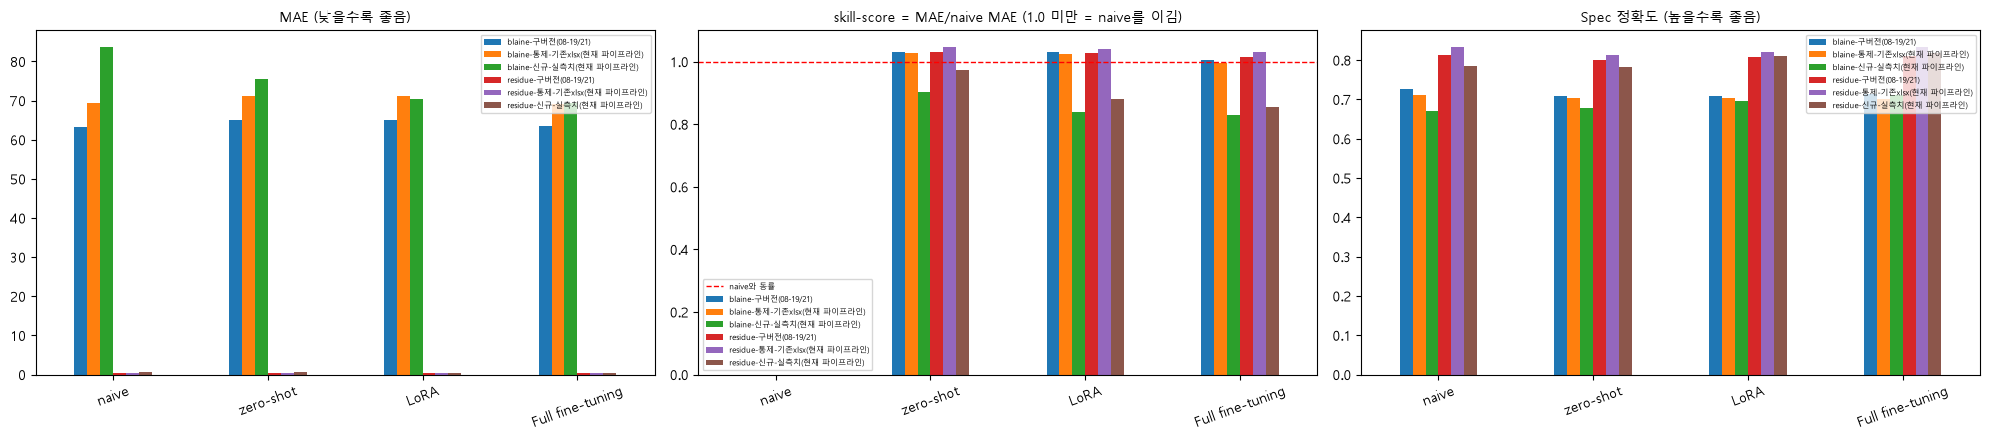

In [4]:
method_order = ["naive"] + METHODS
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))

metrics = ["MAE", "skill_score", "spec_accuracy"]
titles = ["MAE (낮을수록 좋음)", "skill-score = MAE/naive MAE (1.0 미만 = naive를 이김)", "Spec 정확도 (높을수록 좋음)"]

for ax, metric, title in zip(axes, metrics, titles):
    plot_data = {}
    for target in TARGETS:
        for label, summary in summaries.items():
            if metric in summary.columns:
                try:
                    plot_data[f"{target}-{label}"] = summary.loc[target][metric].reindex(method_order)
                except KeyError:
                    continue
    plot_df = pd.DataFrame(plot_data)
    plot_df.plot(kind="bar", ax=ax)
    if metric == "skill_score":
        ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="naive와 동률")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.legend(fontsize=6)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 4. Skill-score 요약 (Chronos-2 MAE / naive MAE)

1.0 미만이면 Chronos-2가 naive baseline(직전 실측값 반복)보다 우수하다는 뜻입니다.
**`통제-기존xlsx` → `신규-실측치` 열의 변화가 xlsx 소스 교체만의 순수한 효과**입니다
(파이프라인이 완전히 동일하므로).

In [5]:
def skill_pivot(summary):
    s = summary.reset_index()
    s = s[s["method"] != "naive"]
    return s.pivot(index="method", columns="target", values="skill_score").reindex(METHODS)


skill_table = pd.concat(
    {label: skill_pivot(summary) for label, summary in summaries.items()},
    axis=1,
)
skill_table.round(4)


구버전(08-19/21)         통제-기존xlsx(현재 파이프라인)          \
target                  blaine residue              blaine residue   
method                                                               
zero-shot               1.0308  1.0319              1.0270  1.0475   
LoRA                    1.0299  1.0271              1.0251  1.0406   
Full fine-tuning        1.0049  1.0149              0.9968  1.0293   

                 신규-실측치(현재 파이프라인)          
target                     blaine residue  
method                                     
zero-shot                  0.9014  0.9744  
LoRA                       0.8403  0.8810  
Full fine-tuning           0.8294  0.8551

## 5. 실제값 vs 예측값 산점도 (신규 실측치 데이터)

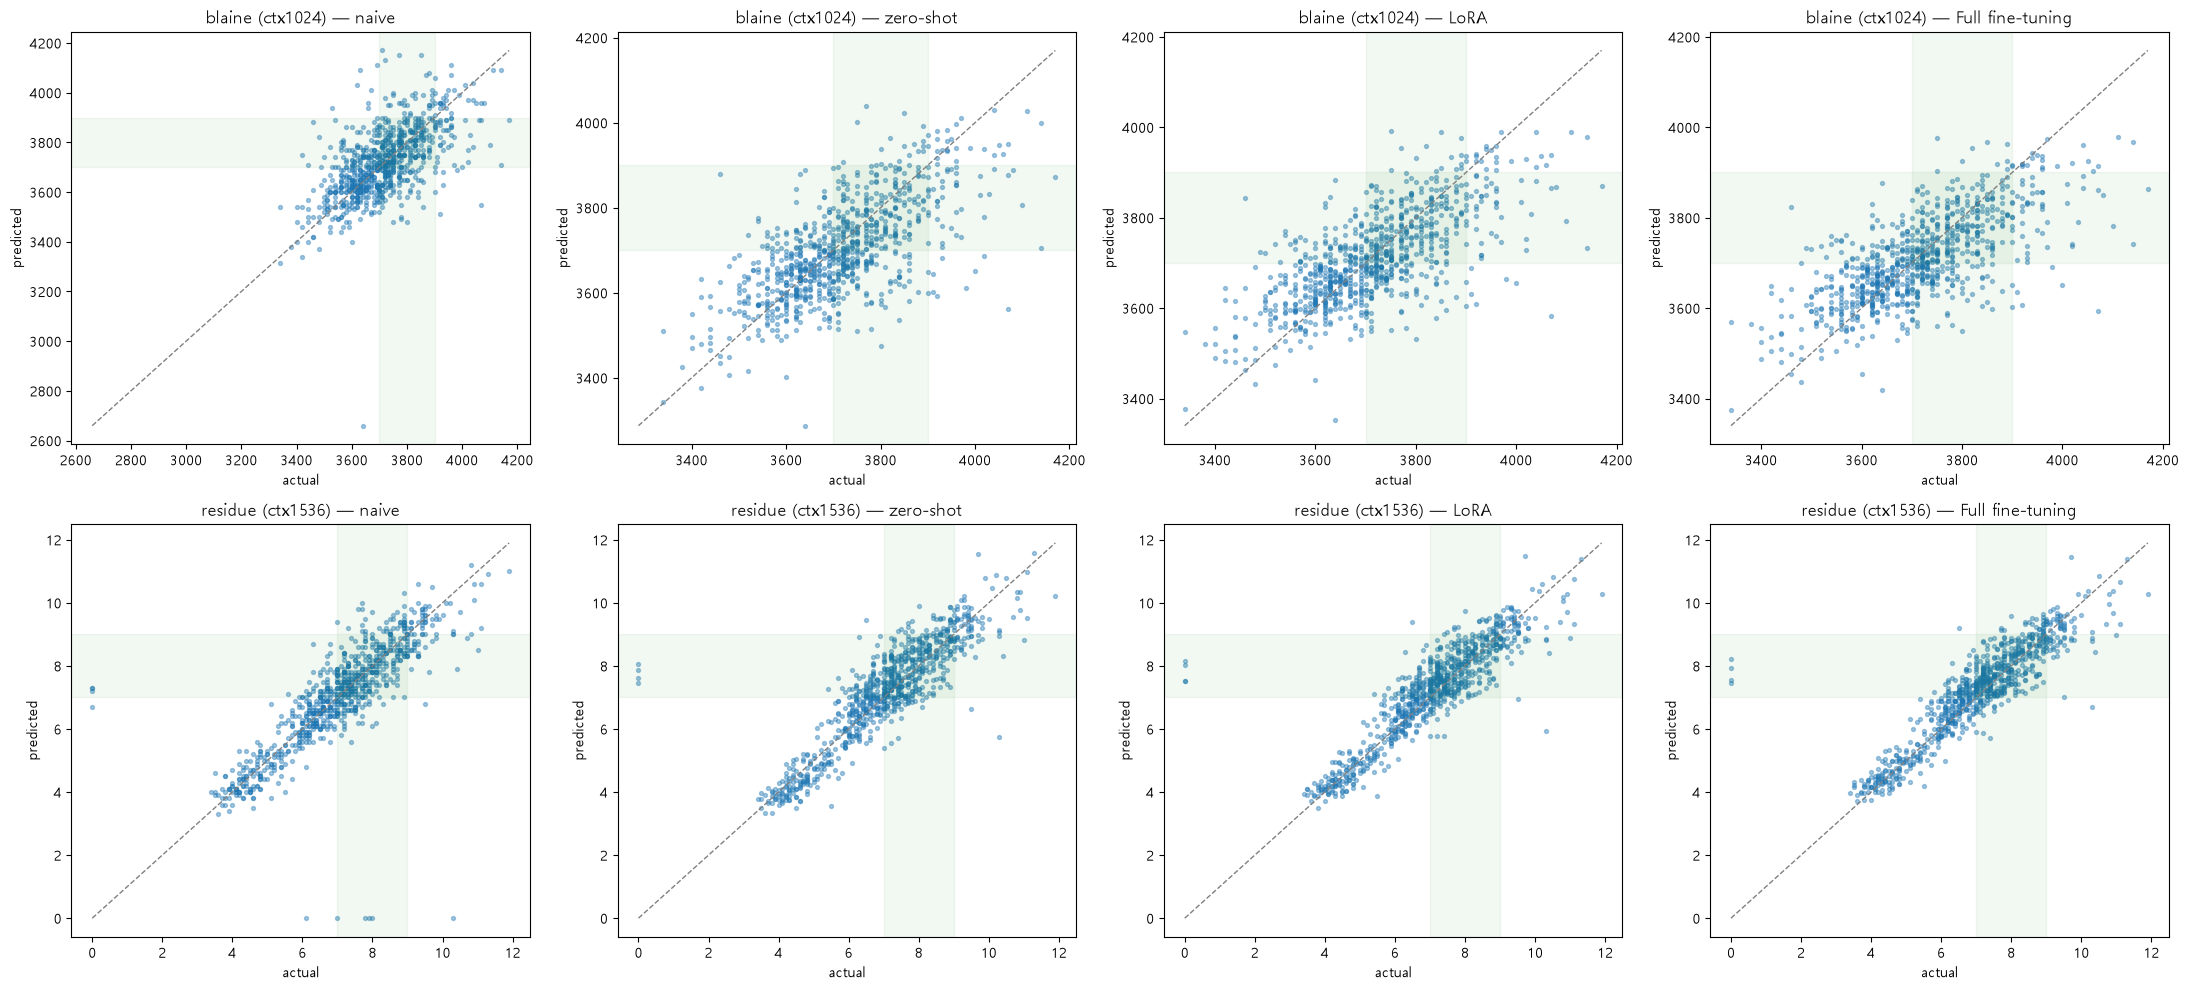

In [6]:
fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(5.5 * (1 + len(METHODS)), 5 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in new_results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", new_results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        ax.scatter(df["actual"], df[pred_col], s=8, alpha=0.4)
        lims = [min(df["actual"].min(), df[pred_col].min()), max(df["actual"].max(), df[pred_col].max())]
        ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1)
        ax.axvspan(lo, hi, color="green", alpha=0.05)
        ax.axhspan(lo, hi, color="green", alpha=0.05)
        ax.set_title(f"{target} (ctx{CTX[target]}) — {label}")
        ax.set_xlabel("actual")
        ax.set_ylabel("predicted")

plt.tight_layout()
plt.show()


## 6. 시계열: 실제값 vs 예측 + 80% 예측구간 (Full fine-tuning, 호기별, 신규 데이터)

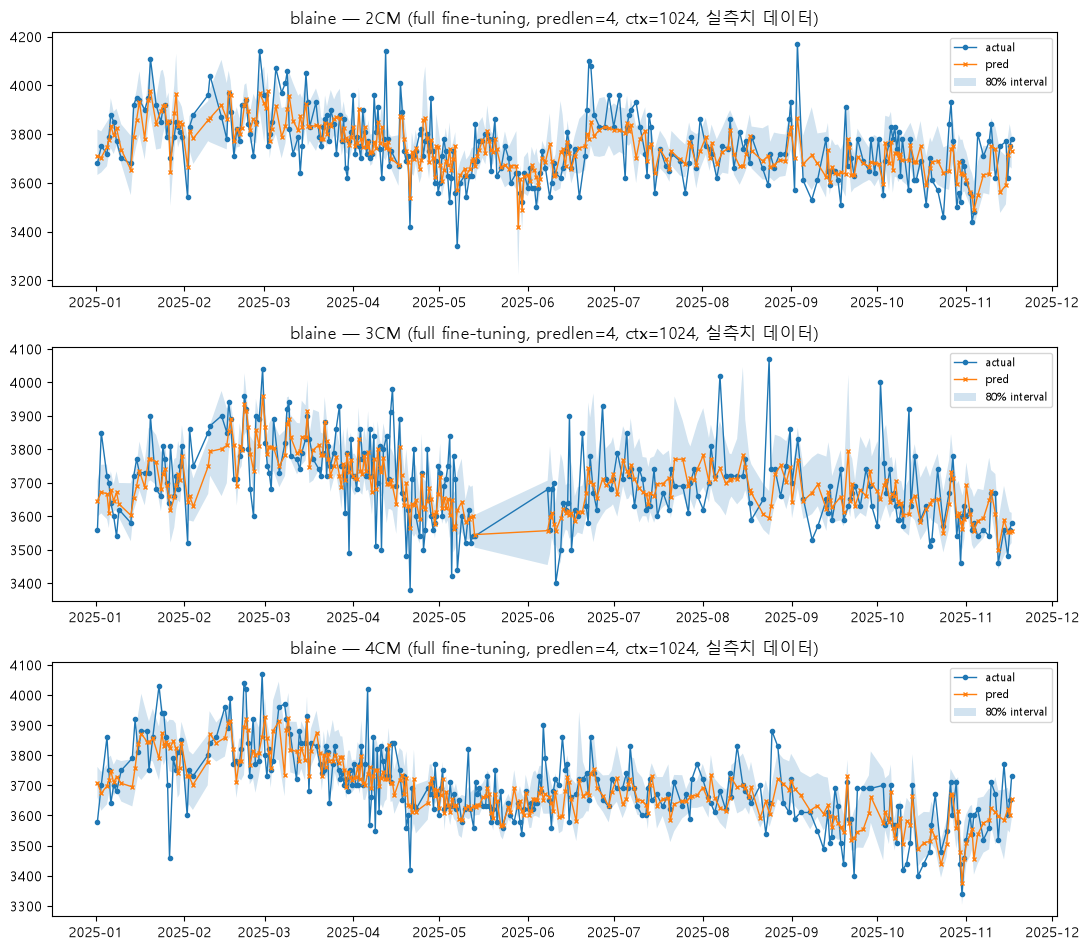

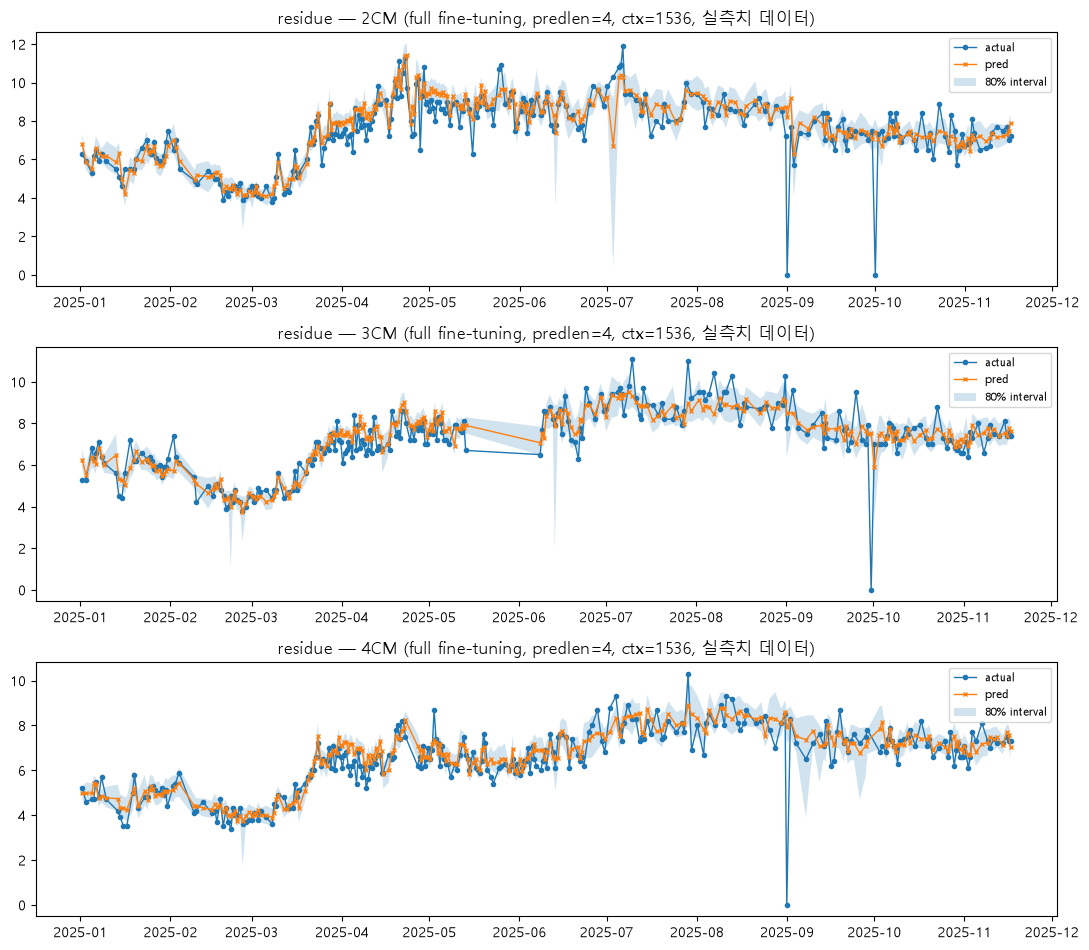

In [7]:
for target in TARGETS:
    df = new_results[target].get("Full fine-tuning")
    if df is None:
        continue
    item_ids = sorted(df["item_id"].unique())
    fig, axes = plt.subplots(len(item_ids), 1, figsize=(11, 3.2 * len(item_ids)), sharex=False)
    if len(item_ids) == 1:
        axes = [axes]
    for ax, item_id in zip(axes, item_ids):
        g = df[df["item_id"] == item_id].sort_values("timestamp")
        ax.plot(g["timestamp"], g["actual"], label="actual", marker="o", markersize=3, linewidth=1)
        ax.plot(g["timestamp"], g["pred"], label="pred", marker="x", markersize=3, linewidth=1)
        ax.fill_between(g["timestamp"], g["pred_q10"], g["pred_q90"], alpha=0.2, label="80% interval")
        ax.set_title(f"{target} — {item_id} (full fine-tuning, predlen=4, ctx={CTX[target]}, 실측치 데이터)")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()


## 7. Confusion Matrix (Spec-in / Spec-out, 신규 데이터)

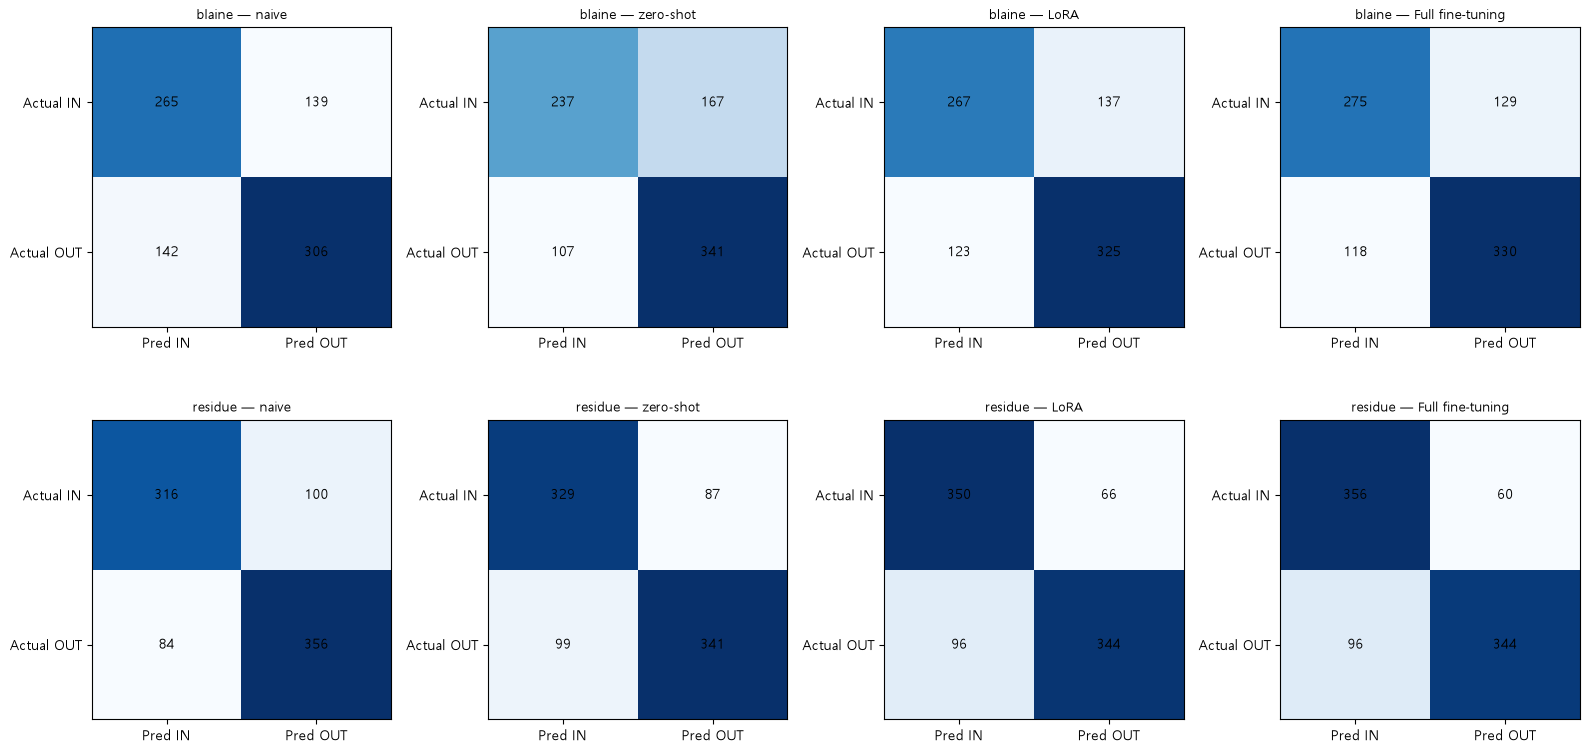

In [8]:
def plot_cm(ax, actual, pred, lo, hi, title):
    actual_cls = categorize(actual, lo, hi)
    pred_cls = categorize(pred, lo, hi)
    cm = confusion_matrix(actual_cls, pred_cls, labels=["IN_SPEC", "OUT_OF_SPEC"])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred IN", "Pred OUT"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual IN", "Actual OUT"])
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(4 * (1 + len(METHODS)), 4 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in new_results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", new_results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        plot_cm(ax, df["actual"].to_numpy(), df[pred_col].to_numpy(), lo, hi, f"{target} — {label}")

plt.tight_layout()
plt.show()


## 8. 결론

**핵심 발견: 파이프라인을 고정하고 xlsx 소스만 바꾼 통제 비교(`통제-기존xlsx` → `신규-실측치`)에서,
6개 조합 전부 skill-score가 뚜렷하게 낮아집니다(=Chronos-2가 naive baseline을 이기는 정도가 훨씬
분명해집니다).**

| target (ctx) | 방식 | MAE 통제→신규 | skill-score 통제→신규 | spec 정확도 통제→신규 | 80% 커버리지 통제→신규 |
|---|---|---|---|---|---|
| blaine (1024) | zero-shot | 71.18 → 75.51 | 1.027 → **0.901** | 70.4%→67.8% | 37.0%→62.0% |
| blaine (1024) | LoRA | 71.04 → 70.39 | 1.025 → **0.840** | 70.2%→69.5% | 36.9%→66.7% |
| blaine (1024) | Full | 69.08 → 69.47 | 0.997 → **0.829** | 70.1%→71.0% | 44.4%→66.1% |
| residue (1536) | zero-shot | 0.416 → 0.554 | 1.048 → **0.974** | 81.2%→78.3% | 40.6%→49.7% |
| residue (1536) | LoRA | 0.413 → 0.501 | 1.041 → **0.881** | 82.0%→81.1% | 42.9%→55.6% |
| residue (1536) | Full | 0.409 → 0.486 | 1.029 → **0.855** | 83.3%→81.8% | 50.0%→67.5% |

(`통제-기존xlsx` = 현재 파이프라인 + 기존 xlsx, `신규-실측치` = 현재 파이프라인 + 실측치 xlsx —
**파이프라인이 완전히 동일하므로 이 표의 변화는 xlsx 소스 교체만의 순수한 효과**입니다. 정확한 수치는
위 `skill_table`/`summaries`를 참고하세요.)

**해석**:
- **naive baseline 자체의 MAE(=skill-score 분모)가 실측치 데이터에서 뚜렷이 나빠집니다**
  (blaine 69.30→83.76, residue 0.40→0.568) — 비실측 시간대에 섞여 있던 carry-forward 값들이 naive
  baseline에게 유리한 "쉬운" 전환 구간을 인위적으로 늘리고 있었던 것으로 보입니다. 예측 과제 자체는
  더 어려워졌는데도 Chronos-2 쪽 MAE는 상대적으로 덜 나빠져(모델은 진짜 신호를 어느 정도 학습),
  결과적으로 상대적 우위가 6개 조합 전부에서, 그리고 통제 조건에서도 일관되게 드러났습니다.
- **통제-기존xlsx 조건에서는 blaine Full만 근소하게 naive를 이기고(skill 0.997) 나머지 5개 조합은
  naive에 졌던 반면, 신규-실측치에서는 6개 조합 전부 확실하게 naive를 이깁니다**(skill 0.83~0.97).
  즉 "Chronos-2가 naive를 잘 못 이긴다"던 기존 결론의 상당 부분이 실제로는 데이터 오염(비실측
  시간대 값 스밈)의 인공물이었을 가능성이 높습니다.
- **80% 예측구간 커버리지도 6개 조합 전부에서 크게 개선**됐습니다(Full 기준 blaine 44%→66%, residue
  50%→68%) — 여전히 목표(80%)엔 못 미치지만, 지금까지 실험 중 가장 근접한 수치입니다.
- spec 정확도는 방향이 엇갈립니다(신규 데이터에서 zero-shot/LoRA는 소폭 하락, Full은 소폭 상승) —
  MAE/skill만큼 일관되게 개선되지는 않았습니다.
- `구버전(08-19/21)` 열은 파이프라인 자체도 다른 시점 것이라 절대값을 직접 비교하면 안 되지만,
  `통제-기존xlsx`와 방향이 대체로 비슷해(residue가 naive를 못 이기고 blaine Full만 근소 우위) 08-31
  파이프라인 변경 자체는 이번 결론에 큰 영향을 주지 않았다는 정황 증거로 볼 수 있습니다.

**결론**: 정식 파이프라인의 `SOURCE_XLSX`를 이 실측치 파일로 교체하는 것을 다음 우선순위로 검토할
가치가 있습니다 — 비실측 시간대 값 오염이 지금까지의 여러 A/B 실험(IQR, prev-density, 물리적 이상치
처리 등) 결론에도 영향을 줬을 가능성이 있어, 교체 후에는 그 실험들도 재검증이 필요합니다.

**한계**: 각 조합 단일 run(시드 고정 안 함).

산출물:
- 빌드: `04_measured_actual_data/build_measured_actual.py` → `data/processed/measured_actual/quality_timeseries.csv`
- 학습/평가 (신규-실측치): `train/run_measured_actual_experiment.sh`, `eval/run_measured_actual_backtest.sh`,
  `eval/backtest_{blaine,residue}_predlen4_ctx{1024,1536}_{zeroshot,lora,full}_measured.csv`,
  체크포인트 `checkpoints/{blaine,residue}_predlen4_ctx{1024,1536}_{lora,full}_measured/`
- 학습/평가 (통제-기존xlsx): `train/run_oldxlsx_ctrl_experiment.sh`, `eval/run_oldxlsx_ctrl_backtest.sh`,
  `eval/backtest_{blaine,residue}_predlen4_ctx{1024,1536}_{zeroshot,lora,full}_oldxlsx.csv`,
  체크포인트 `checkpoints/{blaine,residue}_predlen4_ctx{1024,1536}_{lora,full}_oldxlsx/`
- 결과 노트북: `results_measured_actual.ipynb` (이 파일)
